In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks  
from mpl_toolkits.mplot3d import Axes3D

## 1. Lotka-Volterra: interacción depredador-presa

Tebemos el sistema: 

$$
\begin{cases}
\dfrac{dx}{dt} = \alpha x - \beta xy, \\[6pt]
\dfrac{dy}{dt} = \delta xy - \gamma y,
\end{cases}
\qquad x(0) = x_0, \quad y(0) = y_0,
$$

donde $x(t)$ son las presas y $y(t)$ los depredadores. Como parámetros de referencia tomamos

$$\alpha = 1.0, \quad \beta = 0.5, \quad \gamma = 0.75, \quad \delta = 0.25 .$$



In [3]:
alpha, beta, gamma, delta = 1.0, 0.5, 0.75, 0.25

def f(t, u):
    x, y = u
    return np.array([alpha*x - beta*x*y,
                     delta*x*y - gamma*y])

### Actividad 1. 

Dibujo el campo en la malla $[0, 10] \times [0, 6]$ con 25 puntos por lado. Además del campo agrego las dos rectas donde alguna derivada se anula : $dx/dt = 0$ sobre $y = \alpha/\beta = 2$ y $dy/dt = 0$ sobre $x = \gamma/\delta = 3$.

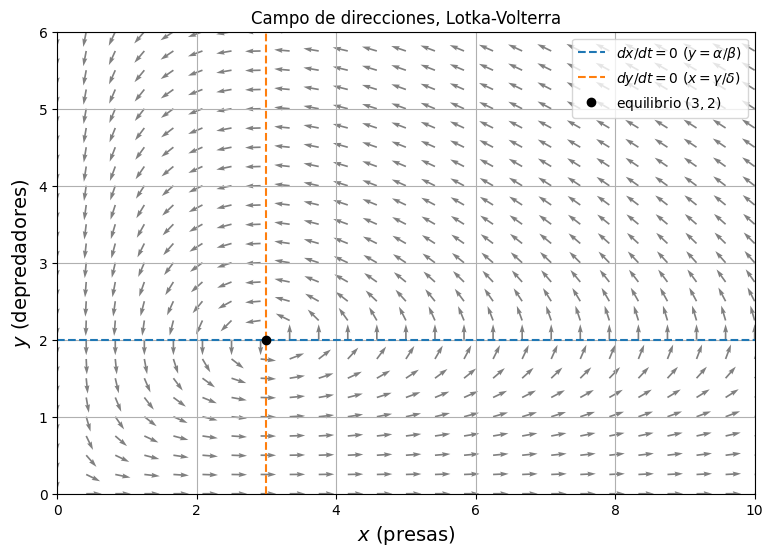

In [4]:
xmax, ymax = 10, 6
X, Y = np.meshgrid(np.linspace(0, xmax, 25),
                   np.linspace(0, ymax, 25))
F, G = alpha*X - beta*X*Y, delta*X*Y - gamma*Y
norma = np.hypot(F, G)

plt.figure(figsize=(9, 6))
plt.quiver(X, Y, F/np.where(norma > 0, norma, 1),
           G/np.where(norma > 0, norma, 1),
           angles="xy", color="gray")


plt.axhline(alpha/beta, color="tab:blue", linestyle="--", label=r"$dx/dt = 0$ ($y = \alpha/\beta$)")
plt.axvline(gamma/delta, color="tab:orange", linestyle="--", label=r"$dy/dt = 0$ ($x = \gamma/\delta$)")
plt.plot(gamma/delta, alpha/beta, "ko", label="equilibrio $(3, 2)$")

plt.xlabel(r"$x$ (presas)", fontsize=14)
plt.ylabel(r"$y$ (depredadores)", fontsize=14)
plt.title("Campo de direcciones, Lotka-Volterra")
plt.xlim(0, xmax)
plt.ylim(0, ymax)
plt.legend(loc="upper right")
plt.grid()
plt.show()

Las flechas indican la dirección. Como $dx/dt = x(\alpha - \beta y)$, las presas crecen cuando $y < \alpha/\beta = 2$  y decrecen cuando hay más de dos depredadores; análogamente $dy/dt = y(\delta x - \gamma)$: los depredadores crecen si $x > \gamma/\delta = 3$ y decrecen si hay menos de tres presas. También, abajo a la derecha (muchas presas, pocos depredadores) las flechas apuntan hacia arriba y a la derecha, lo qe indica que crecen amabas poblaciones; arriba a la derecha crecen los depredadores pero las presas ya van en descenso; arriba a la izquierda decrecen las dos y abajo a la izquierda sólo crecen las presas. Si se eecorren las regiones en ese orden se ve que el campo gira en sentido antihorario alrededor del equilibrio $(3, 2)$. Sobre los ejes el campo es tangente al eje: si $y = 0$ las presas crecen sin control y si $x = 0$ los depredadores mueren. 

### Actividad 2.

Configuración: $\alpha = 1.0$, $\beta = 0.5$, $\gamma = 0.75$, $\delta = 0.25$; intervalo $t \in [0, 30]$ con 3000 puntos guardados. Condiciones iniciales:

$(x_0, y_0) = (2, 2)$, $(5, 1)$ y $(8, 1)$.


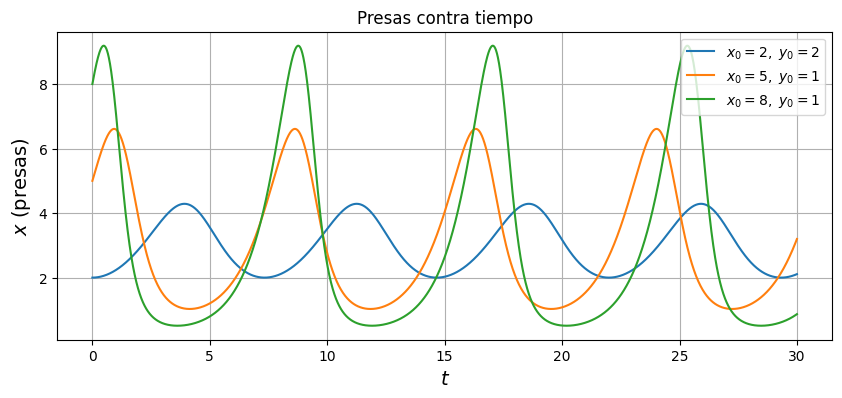

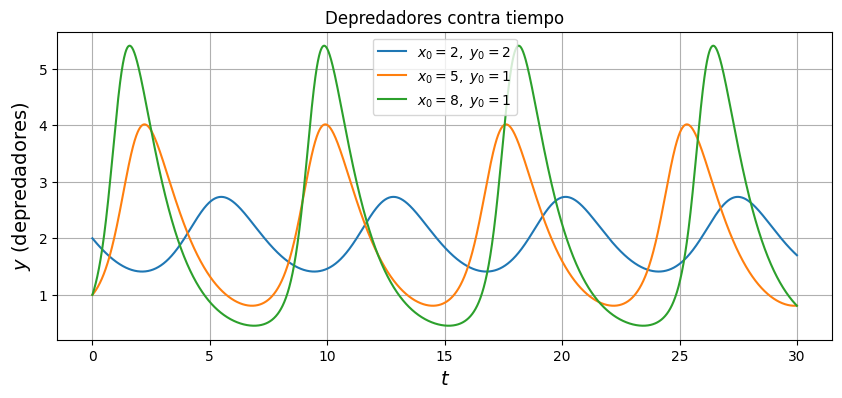

In [5]:
T = 30.0
tiempos = np.linspace(0, T, 3000)

condiciones = [[2, 2], [5, 1], [8, 1]]
soluciones = []
for u0 in condiciones:
    sol = solve_ivp(f, (0, T), u0, method="RK45",
     t_eval=tiempos, rtol=1e-8, atol=1e-10)
    soluciones.append(sol.y.T)
t = sol.t

# presas contra tiempo 
plt.figure(figsize=(10, 4))
for u0, U in zip(condiciones, soluciones):
    plt.plot(t, U[:, 0], label=f"$x_0={u0[0]},\\ y_0={u0[1]}$")
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$x$ (presas)", fontsize=14)
plt.title("Presas contra tiempo")
plt.legend()
plt.grid()
plt.show()

# depredadores contra tiempo
plt.figure(figsize=(10, 4))
for u0, U in zip(condiciones, soluciones):
    plt.plot(t, U[:, 1], label=f"$x_0={u0[0]},\\ y_0={u0[1]}$")
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$y$ (depredadores)", fontsize=14)
plt.title("Depredadores contra tiempo")
plt.legend()
plt.grid()
plt.show()

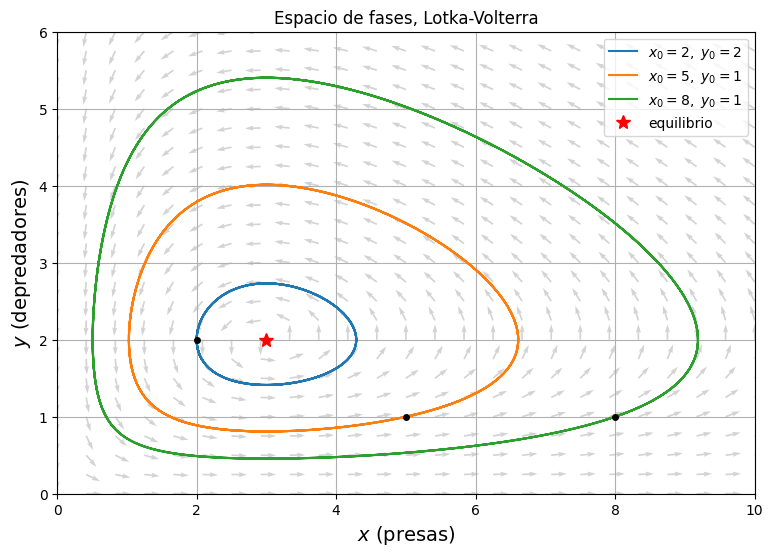

In [6]:
# trayectorias en el espacio de fases sobre el campo de direcciones
plt.figure(figsize=(9, 6))
plt.quiver(X, Y, F/np.where(norma > 0, norma, 1),
           G/np.where(norma > 0, norma, 1),
           angles="xy", color="lightgray")
for u0, U in zip(condiciones, soluciones):
    plt.plot(U[:, 0], U[:, 1], label=f"$x_0={u0[0]},\\ y_0={u0[1]}$")
    plt.plot(u0[0], u0[1], "ko", markersize=4)
plt.plot(gamma/delta, alpha/beta, "r*", markersize=10, label="equilibrio")
plt.xlabel(r"$x$ (presas)", fontsize=14)
plt.ylabel(r"$y$ (depredadores)", fontsize=14)
plt.title("Espacio de fases, Lotka-Volterra")
plt.xlim(0, xmax)
plt.ylim(0, ymax)
plt.legend()
plt.grid()
plt.show()

Asimismo, para ver el desfase entre las dos poblaciones podemos dibujar $x(t)$ y $y(t)$ en la misma gráfica. Tomamos el caso $(x_0, y_0) = (8, 1)$ y medimos con `find_peaks` el instante en que ocurre el primer máximo de cada población y cuánto dura un ciclo.

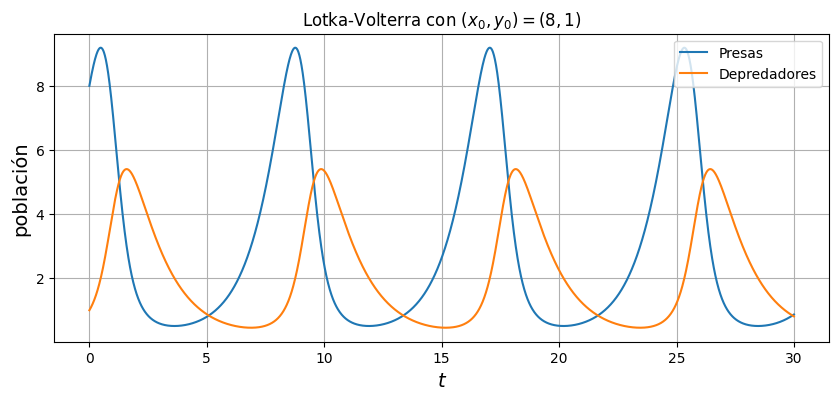

primer máximo de presas en t = 0.48  x = 9.19
primer máximo de depredadores en t = 1.58  y = 5.4
desfase entre máximos: 1.1
periodo aproximado: 8.28
mínimo de presas: 0.509  mínimo de depredadores: 0.455


In [7]:
U = soluciones[2]     

plt.figure(figsize=(10, 4))
plt.plot(t, U[:, 0], label="Presas")
plt.plot(t, U[:, 1], label="Depredadores")
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel("población", fontsize=14)
plt.title(r"Lotka-Volterra con $(x_0, y_0) = (8, 1)$")
plt.legend()
plt.grid()
plt.show()

picos_x, _ = find_peaks(U[:, 0])
picos_y, _ = find_peaks(U[:, 1])
print("primer máximo de presas en t =", round(t[picos_x[0]], 2), " x =", round(U[picos_x[0], 0], 2))
print("primer máximo de depredadores en t =", round(t[picos_y[0]], 2), " y =", round(U[picos_y[0], 1], 2))
print("desfase entre máximos:", round(t[picos_y[0]] - t[picos_x[0]], 2))
print("periodo aproximado:", round(t[picos_x[1]] - t[picos_x[0]], 2))
print("mínimo de presas:", round(U[:, 0].min(), 3), " mínimo de depredadores:", round(U[:, 1].min(), 3))

Aquí se mantuvieron fijos los cuatro parámetros y sólo se cambió el punto de partida. Las tres soluciones son periódicas y en el espacio de fases se ven como curvas cerradas alrededor del equilibrio $(3, 2)$. Entre más lejos del equilibrio empieza la trayectoria, más grande es la órbita y más extremas las oscilaciones: partiendo de $(2, 2)$ las presas se mueven entre 2 y poco más de 4, mientras que partiendo de $(8, 1)$ llegan a 9.19 y bajan hasta 0.51. Es de destacar que el periodo también cambia con la amplitud (las curvas de $x$ vs $t$ no van en fase entre sí aunque tengan los mismos parámetros), lo que no pasaría en un oscilador lineal. En la gráfica con las dos poblaciones juntas el primer máximo de presas ocurre en $t = 0.48$ y el de depredadores en $t = 1.58$, es decir, los depredadores van retrasados 1.1 unidades de tiempo respecto a las presas, y ese retraso se repite en cada ciclo. El mínimo de presas (0.51) y el de depredadores (0.46) también están desfasados, ya que primero se desploman las presas y después los depredadores.

### Actividad 3. 

Condición inicial fija $(x_0, y_0) = (5, 1)$, $t \in [0, 30]$. Caso de referencia: $\alpha = 1.0$, $\beta = 0.5$, $\gamma = 0.75$, $\delta = 0.25$ y en cada experimento se duplica un sólo parámetro:

$\alpha: 1.0 \to 2.0$, $\quad \beta: 0.5 \to 1.0$, $\quad \gamma: 0.75 \to 1.5$, $\quad \delta: 0.25 \to 0.5$.

Escribimos la misma $f$ pero recibiendo los parámetros como argumento.

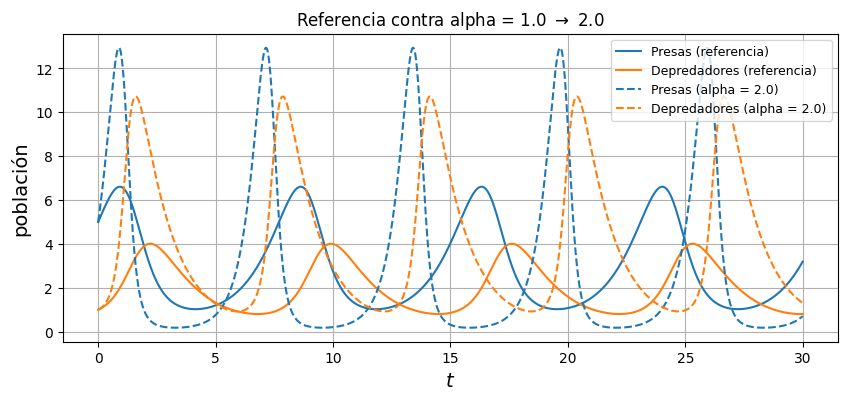

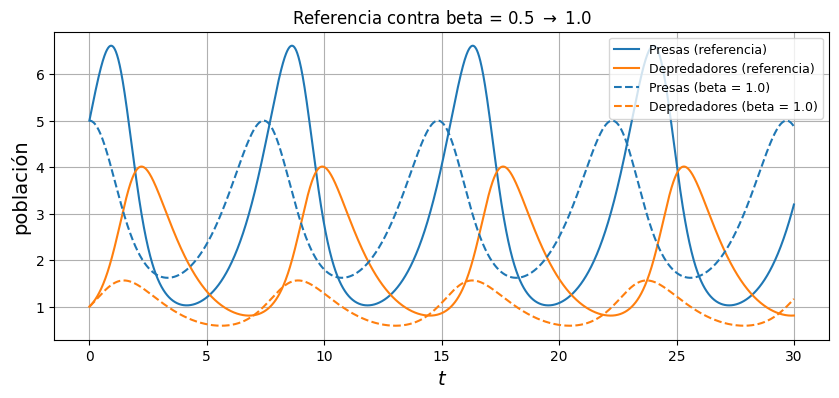

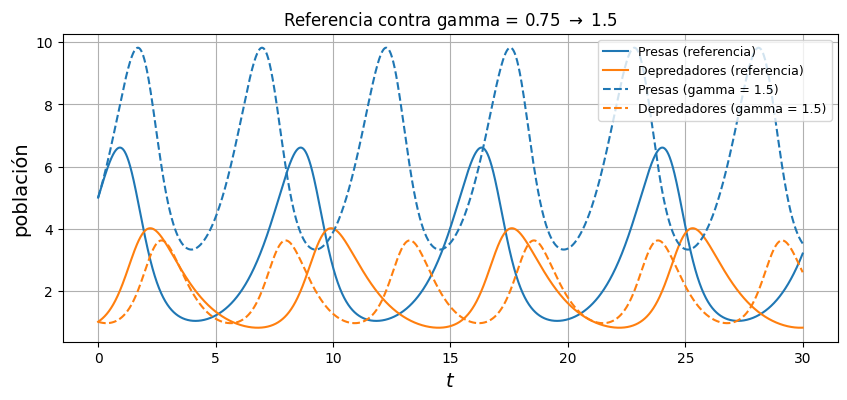

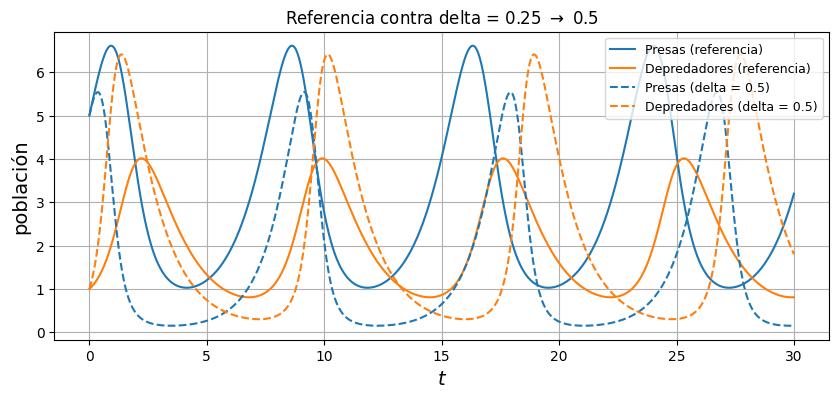

In [8]:
u0 = [5, 1]
referencia = {"alpha": 1.0, "beta": 0.5, "gamma": 0.75, "delta": 0.25}
cambios = {"alpha": 2.0, "beta": 1.0, "gamma": 1.5, "delta": 0.5}

def resolver_lv(p):
    def f_p(t, u):
        x, y = u
        return np.array([p["alpha"]*x - p["beta"]*x*y,
                         p["delta"]*x*y - p["gamma"]*y])
    sol = solve_ivp(f_p, (0, T), u0, method="RK45",
                    t_eval=tiempos, rtol=1e-8, atol=1e-10)
    return sol.y.T

U_ref = resolver_lv(referencia)
resultados = {}
for nombre, valor in cambios.items():
    p = dict(referencia)
    p[nombre] = valor
    resultados[nombre] = resolver_lv(p)

for nombre, U_mod in resultados.items():
    plt.figure(figsize=(10, 4))
    plt.plot(t, U_ref[:, 0], "tab:blue", label="Presas (referencia)")
    plt.plot(t, U_ref[:, 1], "tab:orange", label="Depredadores (referencia)")
    plt.plot(t, U_mod[:, 0], "tab:blue", linestyle="--", label=f"Presas ({nombre} = {cambios[nombre]})")
    plt.plot(t, U_mod[:, 1], "tab:orange", linestyle="--", label=f"Depredadores ({nombre} = {cambios[nombre]})")
    plt.xlabel(r"$t$", fontsize=14)
    plt.ylabel("población", fontsize=14)
    plt.title(f"Referencia contra {nombre} = {referencia[nombre]} $\\to$ {cambios[nombre]}")
    plt.legend(loc="upper right", fontsize=9)
    plt.grid()
    plt.show()

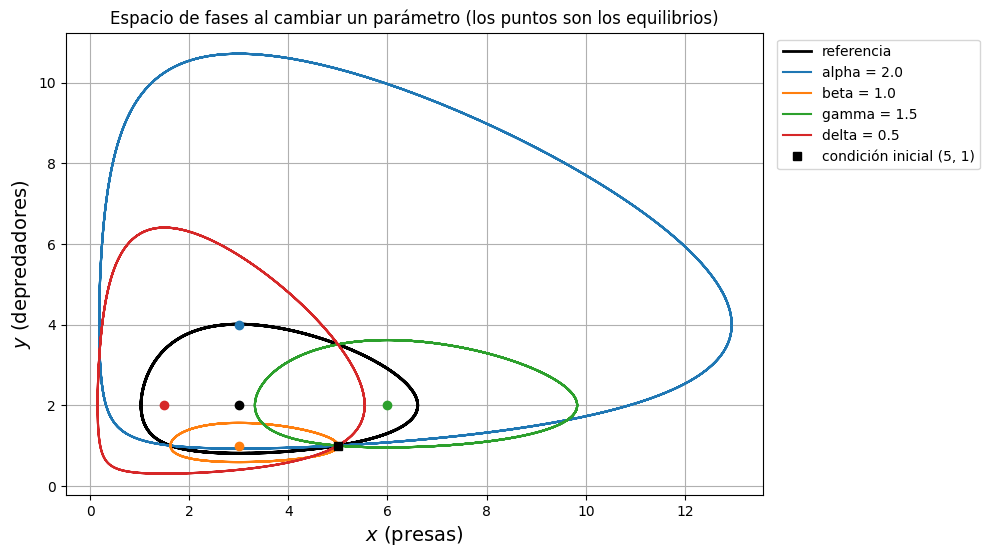

alpha = 2.0:  periodo ~ 6.26,  máx presas = 12.94,  máx depredadores = 10.72
beta = 1.0:  periodo ~ 7.42,  máx presas = 5.00,  máx depredadores = 1.56
gamma = 1.5:  periodo ~ 5.29,  máx presas = 9.83,  máx depredadores = 3.62
delta = 0.5:  periodo ~ 8.78,  máx presas = 5.54,  máx depredadores = 6.41
referencia:  periodo ~ 7.69,  máx presas = 6.61,  máx depredadores = 4.01


In [9]:
plt.figure(figsize=(9, 6))
plt.plot(U_ref[:, 0], U_ref[:, 1], "k", linewidth=2, label="referencia")
for nombre, U_mod in resultados.items():
    plt.plot(U_mod[:, 0], U_mod[:, 1], label=f"{nombre} = {cambios[nombre]}")
    p = dict(referencia); p[nombre] = cambios[nombre]
    plt.plot(p["gamma"]/p["delta"], p["alpha"]/p["beta"], "o", color=plt.gca().lines[-1].get_color())
plt.plot(referencia["gamma"]/referencia["delta"], referencia["alpha"]/referencia["beta"], "ko")
plt.plot(u0[0], u0[1], "ks", markersize=6, label="condición inicial (5, 1)")
plt.xlabel(r"$x$ (presas)", fontsize=14)
plt.ylabel(r"$y$ (depredadores)", fontsize=14)
plt.title("Espacio de fases al cambiar un parámetro (los puntos son los equilibrios)")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))   
plt.grid()
plt.show()

for nombre in cambios:
    picos, _ = find_peaks(resultados[nombre][:, 0])
    print(f"{nombre} = {cambios[nombre]}:  periodo ~ {t[picos[1]] - t[picos[0]]:.2f},  máx presas = {resultados[nombre][:, 0].max():.2f},  máx depredadores = {resultados[nombre][:, 1].max():.2f}")
picos, _ = find_peaks(U_ref[:, 0])
print(f"referencia:  periodo ~ {t[picos[1]] - t[picos[0]]:.2f},  máx presas = {U_ref[:, 0].max():.2f},  máx depredadores = {U_ref[:, 1].max():.2f}")

Aquí la condición inicial es siempre $(5, 1)$ y sólo se duplica un parámetro por experimento. En el espacio de fases lo primero que se nota es que cada cambio mueve el punto de equilibrio, porque $x^* = \gamma/\delta$ y $y^* = \alpha/\beta$: duplicar $\alpha$ sube el equilibrio a $(3, 4)$, duplicar $\beta$ lo baja a $(3, 1)$, duplicar $\gamma$ lo corre a $(6, 2)$ y dullicar $\delta$ lo acerca al origen, a $(1.5, 2)$. Como la condición inicial es la misma, la órbita queda más o menos grande dependiendo de qué tan lejos está $(5, 1)$ del nuevo equilibrio. En suma, ningún cambio destruye el carácter cíclico del modelo: siempre hay órbitas cerradas, sólo cambian su centro, su tamaño y su duración.

### Actividad 4

En general, las presas aumentan mientras $y < \alpha/\beta$ y los depredadores aumentan mientras $x > \gamma/\delta$. Ninguna población decide por sí sola su destino, el signo de $dx/dt$ depende del número de depredadores y el de $dy/dt$ del número de presas.

Si empezamos con muchas presas y pocos depredadores, como en $(8, 1)$, la secuencia que se observa es la siguiente: Con $y = 1 < 2$ las presas todavía crecen un poco (llegan a 9.19 en $t = 0.48$) pero como $x > 3$ los depredadores crecen con rapidez; en cuanto pasan de 2, las presas empiezan a caer. Los depredadores siguen subiendo mientras haya más de 3 presas y tocan su máximo (5.4) en $t = 1.58$, cuando las presas cruzan hacia abajo la recta $x = 3$. A partir de ahí las dos poblaciones caen, las presas hasta 0.51 y despues los depredadores (que sin alimento se desploman en 0.46). Así, con pocos depredadores las presas se recuperan, y cuando de nuevo rebasan 3 presas el ciclo comienza de nuevo

Los máximos no ocurren al mismo tiempo, hay un desfase de 1.1 unidades de tiempo con los depredadores siempre atrás; esto se debe a que el máximo de presas ocurre exactamente cuando $dx/dt = 0$, o sea cuando $y = \alpha/\beta$, y en ese momento hay bastantes presas ($x > \gamma/\delta$) así que $dy/dt > 0$ y los depredadores siguen creciendo. El máximo de depredadores llega cuando las presas ya cayeron hasta $x = \gamma/\delta$. Los depredadores responden a la cantidad de presas que hubo en lugar de a la que hay. 

Recorriendo la órbita verde (de $(8, 1)$) en el sentido del tiempo: sale del punto $(8, 1)$ hacia arriba y a la derecha (crecen las dos especies), en el punto más a la derecha, $x \approx 9.2$, cruza la recta $y = 2$ y empieza a ir a la izquierda mientras sigue subiendo (las presas bajan y los depredadores suben); en el punto más alto, $y \approx 5.4$, cruza la recta $x = 3$ y desde ahí va hacia abajo y a la izquierda (caen las dos); en el extremo izquierdo, $x \approx 0.5$, vuelve a cruzar $y = 2$ y baja hacia la derecha (las presas suben y los depredadores siguen cayendo), hasta que en e punto más bajo, $y \approx 0.46$, cruza otra vez $x = 3$ y cierra el ciclo. Cada uno de esos cuatro tramos corresponde a un cuarto de ciclo de las gráficas temporales: el punto más a la derecha de la órbita es el pico de la curva de presas, el más alto es el pico de la curva de depredadores, y así sucesivamente. Las dos representaciones son esencialmente la misma información, sólo que en la temporal se ve cuándo pasa cada cosa y en el espacio de fases se ve la forma geométrica del ciclo.

## 2. Péndulo simple

La ecuación $\ddot\theta + \frac{g}{\ell}\sin\theta = 0$ es el sistema de primer orden

$$
\begin{cases}
\dfrac{d\theta}{dt} = \omega, \\[6pt]
\dfrac{d\omega}{dt} = -\dfrac{g}{\ell}\sin\theta,
\end{cases}
\qquad \theta(0) = \theta_0, \quad \omega(0) = \omega_0 .
$$

Usamos $g = 9.81$ y como longitud de referencia $\ell = 1$ con estos valores $\sqrt{g/\ell} \approx 3.13$, así que el periodo de las oscilaciones pequeñas debería ser $2\pi\sqrt{\ell/g} \approx 2.006$.

In [10]:
g = 9.81
ell = 1.0

def f(t, u):
    theta, omega = u
    return np.array([omega, -(g/ell)*np.sin(theta)])

### Actividad 1 

Malla $\theta \in [-2\pi, 2\pi]$, $\omega \in [-8, 8]$, 25 puntos por lado, de modo que aparezcan los equilibrios $\theta = 0, \pm\pi, \pm 2\pi$. Se dibuja también la separatriz $\omega = \pm 2\sqrt{g/\ell}\,\cos(\theta/2)$. 

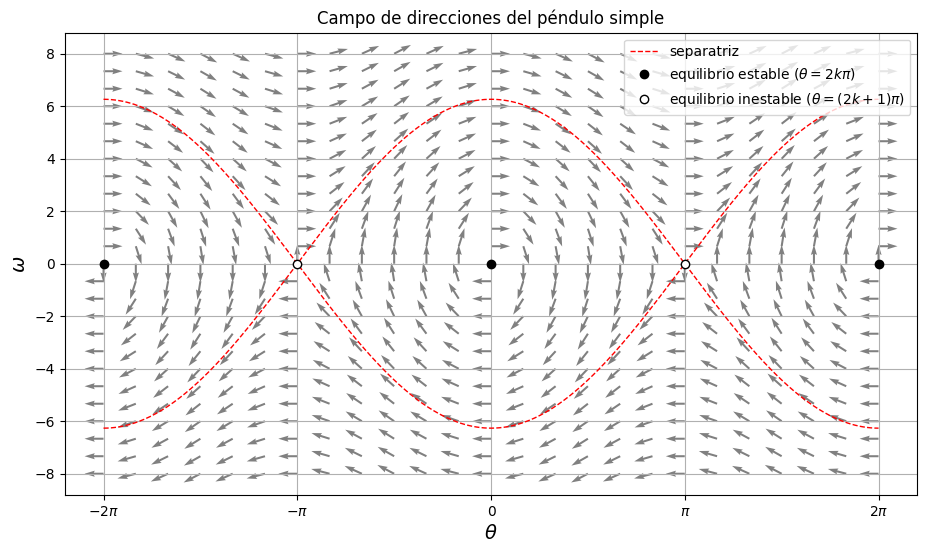

In [11]:
Theta, Omega = np.meshgrid(np.linspace(-2*np.pi, 2*np.pi, 25),
                           np.linspace(-8, 8, 25))
F = Omega
G = -(g/ell)*np.sin(Theta)
norma = np.hypot(F, G)

th = np.linspace(-2*np.pi, 2*np.pi, 400)
separatriz = 2*np.sqrt(g/ell)*np.cos(th/2)

plt.figure(figsize=(11, 6))
plt.quiver(Theta, Omega, F/np.where(norma > 0, norma, 1),
           G/np.where(norma > 0, norma, 1),
           angles="xy", color="gray")
plt.plot(th, separatriz, "r--", linewidth=1, label="separatriz")
plt.plot(th, -separatriz, "r--", linewidth=1)
plt.plot([-2*np.pi, 0, 2*np.pi], [0, 0, 0], "ko", label=r"equilibrio estable ($\theta = 2k\pi$)")
plt.plot([-np.pi, np.pi], [0, 0], "ko", markerfacecolor="white", label=r"equilibrio inestable ($\theta = (2k+1)\pi$)")
plt.xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi], [r"$-2\pi$", r"$-\pi$", "0", r"$\pi$", r"$2\pi$"])
plt.xlabel(r"$\theta$", fontsize=14)
plt.ylabel(r"$\omega$", fontsize=14)
plt.title("Campo de direcciones del péndulo simple")
plt.legend(loc="upper right")
plt.grid()
plt.show()

El campo del péndulo es periódico en $\theta$ con periodo $2\pi$, por eso lo que se ve alrededor de $\theta = 0$ se repite en $\pm 2\pi$. Como $d\theta/dt = \omega$, en la mitad superior del plano ($\omega > 0$) todas las flechas apuntan a la derecha y en la inferior a la izquierda; la componente vertical, $-(g/\ell)\sin\theta$, es la que cambia de signo con la posición. Físicamente, $\theta = \pi$ es el péndulo parado de cabeza, y la línea roja con putns que sale y entra es la frontera entre las dos clases de movimiento: adentro de ella el péndulo oscila, afuera da vueltas completas. Sobre el eje $\omega = 0$ el campo es vertical. 

### Actividad 2

Configuración: $g = 9.81$, $\ell = 1$, $t \in [0, 30]$ con 3000 puntos (para las gráficas temporales se muestan sólo los primeros 10 segundos). Condiciones iniciales $(\theta_0, \omega_0)$:

- $(0.3, 0)$: oscilación pequeña,
- $(2.5, 0)$: oscilación grande,
- $(\pi - 0.05, 0)$: se suelta casi desde la posición superior,
- $(0, 5)$: se empuja desde abajo con energía insuficiente para dar la vuelta ($5 < 2\sqrt{g/\ell} \approx 6.26$),
- $(0, 7)$: se empuja con energía suficiente, da vueltas completas.

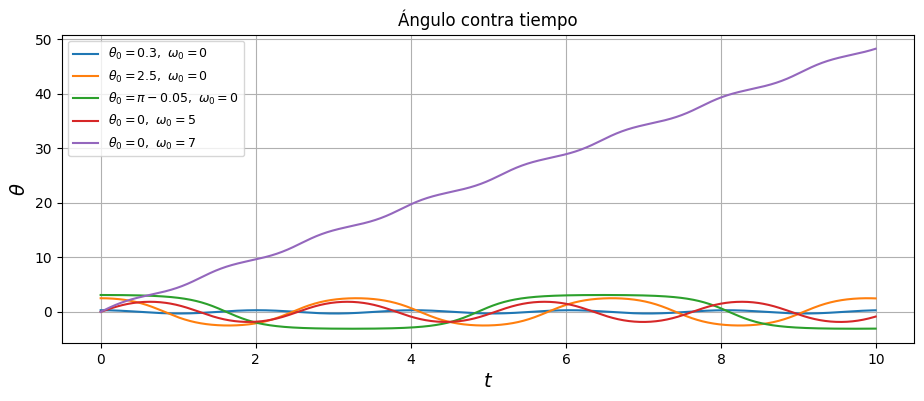

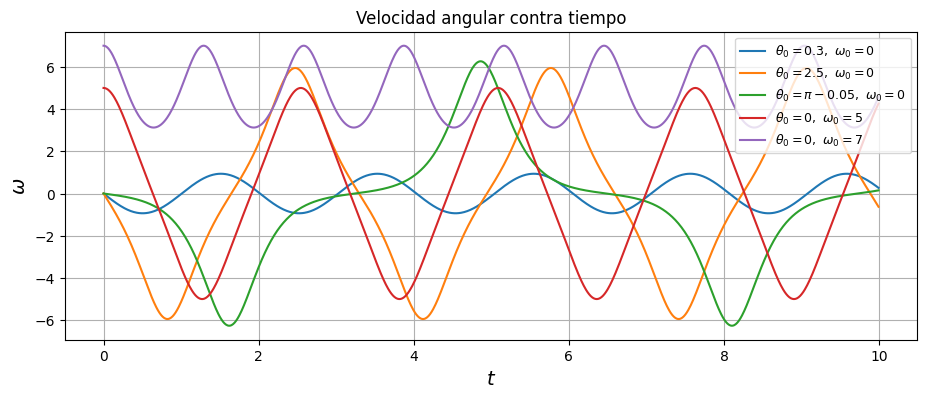

In [12]:
T = 30.0
tiempos = np.linspace(0, T, 3000)

condiciones = [[0.3, 0.0], [2.5, 0.0], [np.pi - 0.05, 0.0], [0.0, 5.0], [0.0, 7.0]]
etiquetas = [r"$\theta_0=0.3,\ \omega_0=0$", r"$\theta_0=2.5,\ \omega_0=0$",
             r"$\theta_0=\pi-0.05,\ \omega_0=0$", r"$\theta_0=0,\ \omega_0=5$", r"$\theta_0=0,\ \omega_0=7$"]
soluciones = []
for u0 in condiciones:
    sol = solve_ivp(f, (0, T), u0, method="RK45",
                    t_eval=tiempos, rtol=1e-8, atol=1e-10)
    soluciones.append(sol.y.T)
t = sol.t
ventana = t <= 10

plt.figure(figsize=(11, 4))
for et, U in zip(etiquetas, soluciones):
    plt.plot(t[ventana], U[ventana, 0], label=et)
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$\theta$", fontsize=14)
plt.title("Ángulo contra tiempo")
plt.legend(loc="upper left", fontsize=9)
plt.grid()
plt.show()

plt.figure(figsize=(11, 4))
for et, U in zip(etiquetas, soluciones):
    plt.plot(t[ventana], U[ventana, 1], label=et)
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$\omega$", fontsize=14)
plt.title("Velocidad angular contra tiempo")
plt.legend(loc="upper right", fontsize=9)
plt.grid()
plt.show()

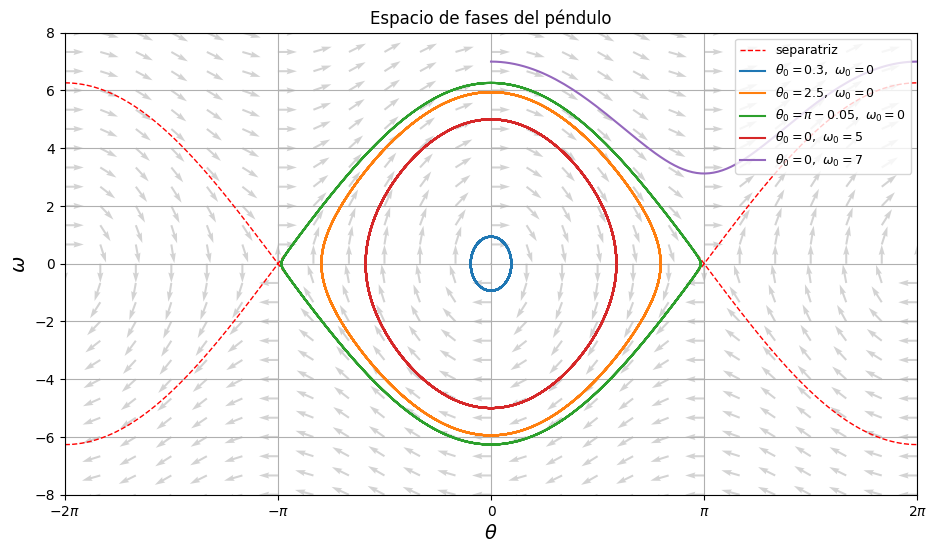

$\theta_0=0.3,\ \omega_0=0$:  periodo ~ 2.011,  |theta| máx = 0.300
$\theta_0=2.5,\ \omega_0=0$:  periodo ~ 3.301,  |theta| máx = 2.500
$\theta_0=\pi-0.05,\ \omega_0=0$:  periodo ~ 6.482,  |theta| máx = 3.092
$\theta_0=0,\ \omega_0=5$:  periodo ~ 2.541,  |theta| máx = 1.849
periodo de oscilaciones pequeñas, 2*pi*sqrt(l/g) = 2.006
theta final del caso con omega_0 = 7: 146.4 rad, es decir 23.3 vueltas


In [13]:
plt.figure(figsize=(11, 6))
plt.quiver(Theta, Omega, F/np.where(norma > 0, norma, 1),
           G/np.where(norma > 0, norma, 1),
           angles="xy", color="lightgray")
plt.plot(th, separatriz, "r--", linewidth=1, label="separatriz")
plt.plot(th, -separatriz, "r--", linewidth=1)
for et, U in zip(etiquetas, soluciones):
    plt.plot(U[:, 0], U[:, 1], label=et)
plt.xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi], [r"$-2\pi$", r"$-\pi$", "0", r"$\pi$", r"$2\pi$"])
plt.xlim(-2*np.pi, 2*np.pi)
plt.ylim(-8, 8)
plt.xlabel(r"$\theta$", fontsize=14)
plt.ylabel(r"$\omega$", fontsize=14)
plt.title("Espacio de fases del péndulo")
plt.legend(loc="upper right", fontsize=9)
plt.grid()
plt.show()


for et, U in zip(etiquetas[:4], soluciones[:4]):
    picos, _ = find_peaks(U[:, 0])
    print(f"{et}:  periodo ~ {t[picos[1]] - t[picos[0]]:.3f},  |theta| máx = {abs(U[:, 0]).max():.3f}")
print("periodo de oscilaciones pequeñas, 2*pi*sqrt(l/g) =", round(2*np.pi*np.sqrt(ell/g), 3))
print("theta final del caso con omega_0 = 7:", round(soluciones[4][-1, 0], 1), "rad, es decir", round(soluciones[4][-1, 0]/(2*np.pi), 1), "vueltas")

Aquí, se fijó $g = 9.81$, $\ell = 1$ y varió el punto de partida. Los cuatro primeros casos oscilan y el último rota, y la diferencia se ve en las dos representaciones: en las gráficas temporales las oscilaciones tienen $\theta$ acotado y periódico, alternando de signo, mientras que en el caso $\omega_0 = 7$ el ángulo crece de manera monótona (casi lineal) con pequeñas ondulaciones (llega a 146.4 rad, unas 23 vueltas, en 30 segundos) y $\omega$ nunca cambia de signo, sólo oscila. El caso $\pi - 0.05$ es interesante: en la gráfica de $\theta$ contra $t$ se ve que el péndulo se queda varado cerca de la posición superior un buen rato, cae rápidamente, pasa por abajo a alta velocidad ($|\omega| \approx 6.2$), sube casi hasta $-\pi$ y vuelve a quedarse quieto ahí; su órbita en el espacio de fases está pegada a la separatriz por dentro.

### Actividad 3 

Condición inicial fija $(\theta_0, \omega_0) = (1, 0)$, $g = 9.81$, $t \in [0, 30]$ (sólo primeros 10 segundos). Caso de referencia $\ell = 1$ comparándolo con $\ell = 0.5$ y $\ell = 2$.

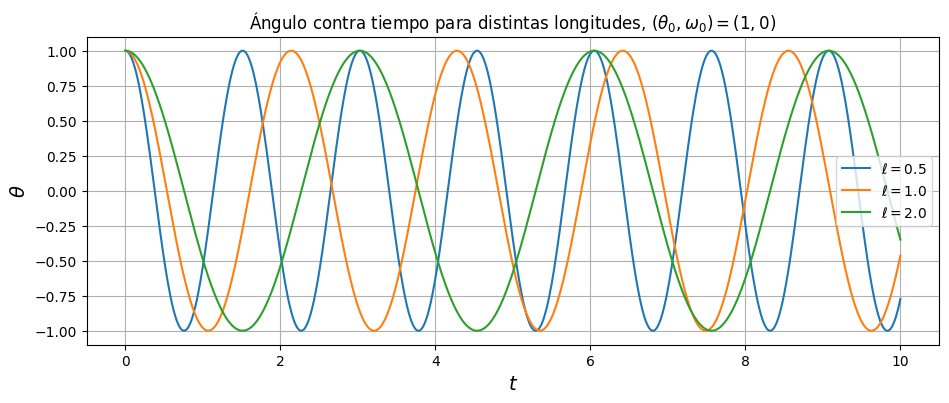

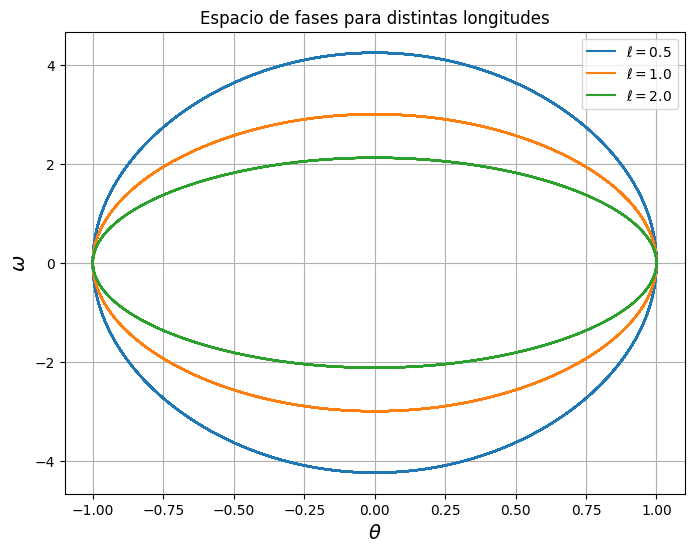

l = 0.5:  periodo medido = 1.520,  2*pi*sqrt(l/g) = 1.419,  |omega| máx = 4.247
l = 1.0:  periodo medido = 2.140,  2*pi*sqrt(l/g) = 2.006,  |omega| máx = 3.003
l = 2.0:  periodo medido = 3.020,  2*pi*sqrt(l/g) = 2.837,  |omega| máx = 2.124


In [14]:
g = 9.81
T = 30.0
tiempos = np.linspace(0, T, 3001)
t = tiempos
ventana = t <= 10         

def f(t, u, ell=1.0):
    theta, omega = u
    return [omega, -(g / ell) * np.sin(theta)]

u0 = [1.0, 0.0]
longitudes = [0.5, 1.0, 2.0]
soluciones_l = []
for ell in longitudes:
    sol = solve_ivp(f, (0, T), u0, method="RK45", t_eval=tiempos,
                    args=(ell,), rtol=1e-8, atol=1e-10)
    soluciones_l.append(sol.y.T)

plt.figure(figsize=(11, 4))
for l, U in zip(longitudes, soluciones_l):
    plt.plot(t[ventana], U[ventana, 0], label=fr"$\ell = {l}$")
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$\theta$", fontsize=14)
plt.title(r"Ángulo contra tiempo para distintas longitudes, $(\theta_0, \omega_0) = (1, 0)$")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
for l, U in zip(longitudes, soluciones_l):
    plt.plot(U[:, 0], U[:, 1], label=fr"$\ell = {l}$")
plt.xlabel(r"$\theta$", fontsize=14)
plt.ylabel(r"$\omega$", fontsize=14)
plt.title("Espacio de fases para distintas longitudes")
plt.legend()
plt.grid()
plt.show()

for l, U in zip(longitudes, soluciones_l):
    picos, _ = find_peaks(U[:, 0])
    print(f"l = {l}:  periodo medido = {t[picos[1]] - t[picos[0]]:.3f},  "
          f"2*pi*sqrt(l/g) = {2*np.pi*np.sqrt(l/g):.3f},  "
          f"|omega| máx = {np.abs(U[:, 1]).max():.3f}")

Aquí lo que cambia es la longitud, con la misma condición inicial $(\theta_0, \omega_0) = (1, 0)$. Al acortar el péndulo oscila más rápido y al alargarlo más despacio: los periodos medidos fueron 1.520, 2.140 y 3.020 para $\ell = 0.5, 1, 2$. Los cocientes entre ellos son $1.520/2.140 = 0.710$ y $3.020/2.140 = 1.411$, prácticamente $1/\sqrt{2}$ y $\sqrt{2}$, así que el periodo escala como $\sqrt{\ell}$ tal como dice la fórmula. 

### Actividad 4

Una oscilación y una rotación se distinguen de inmediato: en las graficas temporales la oscilación tiene $\theta$ acotado y cambiando de signo, y $\omega$ pasando por cero dos veces por ciclo; en la rotación $\theta$ crece sin cota y $\omega$ conserva su signo. En el espacio de fases la oscilación es una curva cerrada que encierra a $(0, 0)$ y la rotación una curva abierta, y la linea que separa $\omega = \pm 2\sqrt{g/\ell}\cos(\theta/2)$ es la frontera exacta entre ambas: con $\omega_0 = 5$ (menor que $2\sqrt{g/\ell} \approx 6.26$) el péndulo oscila y con $\omega_0 = 7$ rota.

La rapidez angular $|\omega|$ aumenta cuando el péndulo se mueve hacia la posición inferior y disminuye cuando se aleja de ella. Esto se ve en el campo: $d\omega/dt = -(g/\ell)\sin\theta$ tiene el signo contrario a $\theta$ (en $(-\pi, \pi)$), así que siempre empuja hacia $\theta = 0$. Por eso en todas las órbitas cerradas $|\omega|$ es máxima al cruzar $\theta = 0$ y mínima en los extremos, y en la rotación $\omega$ es máxima ($7$) al pasar por abajo y mínima ($\approx 3.1$) al pasar por arriba, en $\theta = \pi$, sin llegar a detenerse. El sentido del movimiento sólo cambia donde $\omega = 0$, es decir, en los puntos de retorno de las oscilaciones; en una rotación nunca cambia.

Los puntos con $\omega = 0$ son los instantes en que el péndulo está momentáneamente detenido, los extremos de la oscilación. Pero no permanece en reposo: en ese punto $d\omega/dt = -(g/\ell)\sin\theta \neq 0$ (salvo en $\theta = 0$ o $\pi$), así que la aceleración lo regresa de inmediato. Los únicos puntos donde sí se queda en reposo son los equilibrios $(0, 0)$ y $(\pm\pi, 0)$, y de ellos sólo el primero es estable.

Desde $\theta_0 = 0.3$ el movimiento es casi armónico, la curva de $\theta$ es un coseno limpio, el periodo (2.011) es el del péndulo lineal y la órbita es una elipse. Desde $\theta_0 = \pi - 0.05$ el péndulo pasa la mayor parte del tiempo casi inmóvil cerca de la posición superior, porque ahí $\sin\theta \approx 0.05$ y la aceleración es minúscula, y luego cae de golpe, la curva de $\theta$ se parece más a una onda cuadrada suavizada y el periodo se triplica (6.48).

Al modificar la longitud el péndulo cambia de ritmo pero no de forma: el periodo va como $\sqrt{\ell}$ (medimos 1.52, 2.14 y 3.02 para $\ell = 0.5, 1, 2$) y la velocidad máxima como $1/\sqrt{\ell}$, mientras que la amplitud angular no depende de $\ell$.

Siguiendo la órbita naranja ($\theta_0 = 2.5$, $\omega_0 = 0$) en el sentido del tiempo: parte del punto $(2.5, 0)$, que es el péndulo sostenido a unos 143 grados de la vertical y soltado. Va hacia abajo en el plano de fases (ω negativo, el péndulo cae hacia la izquierda, hacia $\theta = 0$) ganando velocidad; cruza $\theta = 0$ en el punto más bajo de la órbita con $\omega \approx -6$, que es el paso por la vertical a máxima rapidez; sigue hacia la izquierda pero frenando, hasta tocar el eje en $(-2.5, 0)$, donde se detiene un instante del otro lado; de ahí sube por la mitad superior del plano (ω positivo, el péndulo regresa hacia la derecha), vuelve a pasar por abajo con $\omega \approx +6$ y frena hasta llegar de nuevo a $(2.5, 0)$. Asi, cada vuelta a la órbita es una oscilación completa, que dura 3.30 unidades de tiempo.

## 3. Sistema de Lorenz

$$
\begin{cases}
\dot x = \sigma (y - x), \\
\dot y = x(\rho - z) - y, \\
\dot z = xy - \beta z,
\end{cases}
$$

con los parámetros del caso caótico: $\sigma = 10$, $\rho = 28$, $\beta = 8/3$. Aquí se usa $T = 40$ y se guardan 8000 puntos en lugar de 3000 (las tolerancias son las mismas; el paso interno lo sigue decidiendo `RK45`). 

In [15]:
sigma, rho, beta = 10.0, 28.0, 8.0/3.0

def f(t, u):
    x, y, z = u
    return np.array([sigma*(y - x),
                     x*(rho - z) - y,
                     x*y - beta*z])

T = 40.0
tiempos = np.linspace(0, T, 8000)

### Actividad 1. Distintas condiciones iniciales

Configuración: $\sigma = 10$, $\rho = 28$, $\beta = 8/3$, $t \in [0, 40]$. Condiciones iniciales $(x_0, y_0, z_0) = (1, 1, 1)$, $(-5, 5, 20)$ y $(10, 10, 10)$.

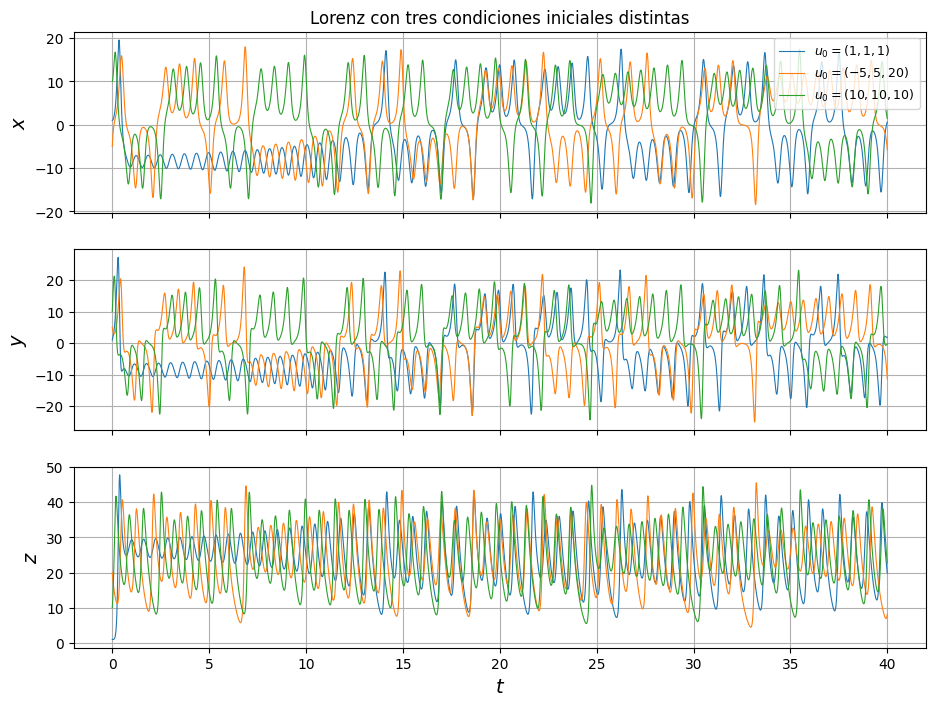

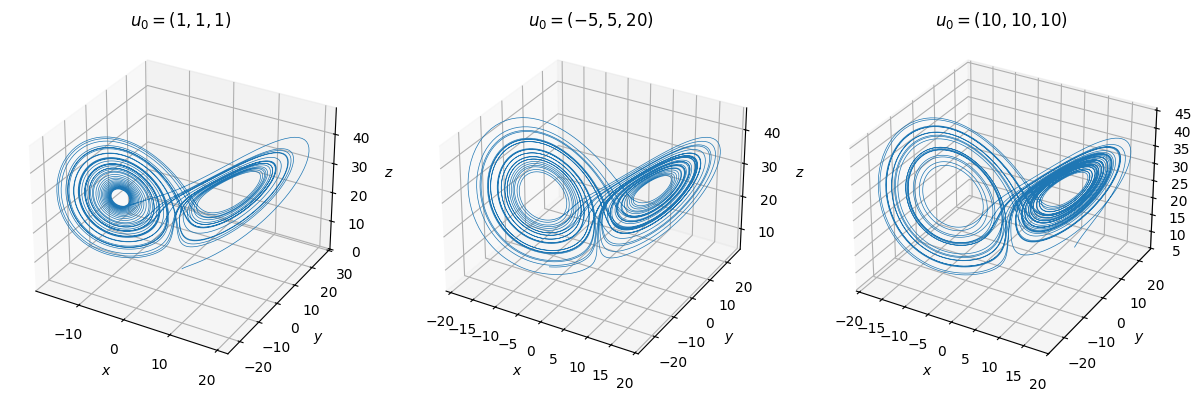

In [16]:
condiciones = [[1.0, 1.0, 1.0], [-5.0, 5.0, 20.0], [10.0, 10.0, 10.0]]
soluciones = []
for u0 in condiciones:
    sol = solve_ivp(f, (0, T), u0, method="RK45",
                    t_eval=tiempos, rtol=1e-8, atol=1e-10)
    soluciones.append(sol.y.T)
t = sol.t

fig, ejes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for u0, U in zip(condiciones, soluciones):
    et = f"$u_0 = ({u0[0]:g}, {u0[1]:g}, {u0[2]:g})$"
    ejes[0].plot(t, U[:, 0], label=et, linewidth=0.8)
    ejes[1].plot(t, U[:, 1], label=et, linewidth=0.8)
    ejes[2].plot(t, U[:, 2], label=et, linewidth=0.8)
for eje, var in zip(ejes, ["x", "y", "z"]):
    eje.set_ylabel(f"${var}$", fontsize=14)
    eje.grid()
ejes[0].legend(loc="upper right", fontsize=9)
ejes[2].set_xlabel(r"$t$", fontsize=14)
ejes[0].set_title("Lorenz con tres condiciones iniciales distintas")
plt.show()

fig = plt.figure(figsize=(15, 5))
for i, (u0, U) in enumerate(zip(condiciones, soluciones)):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.plot(U[:, 0], U[:, 1], U[:, 2], linewidth=0.5)
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_zlabel("$z$")
    ax.set_title(f"$u_0 = ({u0[0]:g}, {u0[1]:g}, {u0[2]:g})$")
plt.show()

Con las tres condiciones iniciales las series de tiempo son distintas: cambian de signo en momentos diferentes y sin ningún patrón que las relacione entre sí, y tampoco se parecen a nada periódico. Sin embargo, las tres trayectorias tridimensionales tienen la misma forma de mariposa con dos lóbulos, y el rango de valores que visitan es el mismo (más o menos $x, y \in [-20, 20]$ y $z$ entre 7 y 48). Esto es, la solución particular depende muchísimo del punto de partida, pero el objeto sobre el que termina viviendo la trayectoria, el atractor, es el mismo. 

### Actividad 2 

Para $u_0 = (1, 1, 1)$ dibujamos las proyecciones de la trayectoria sobre los planos $(x, y)$, $(x, z)$, $(y, z)$ y la trayectoria completa en $(x, y, z)$.

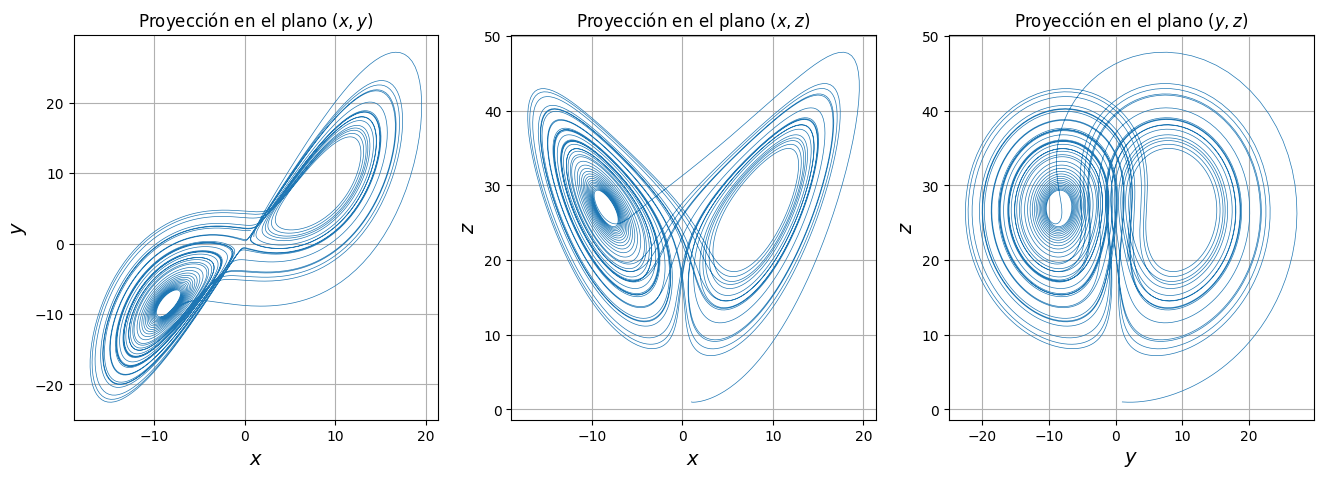

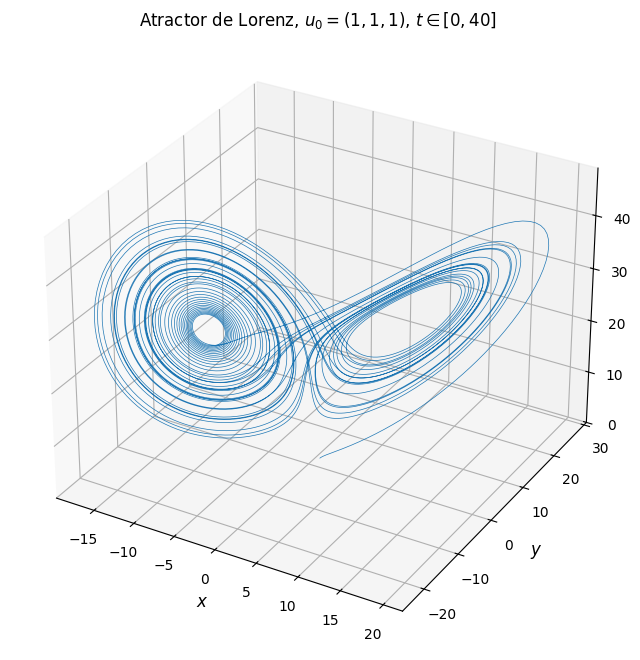

In [17]:
U = soluciones[0]

fig, ejes = plt.subplots(1, 3, figsize=(16, 5))
pares = [(0, 1, "x", "y"), (0, 2, "x", "z"), (1, 2, "y", "z")]
for eje, (i, j, a, b) in zip(ejes, pares):
    eje.plot(U[:, i], U[:, j], linewidth=0.5)
    eje.set_xlabel(f"${a}$", fontsize=14)
    eje.set_ylabel(f"${b}$", fontsize=14)
    eje.set_title(f"Proyección en el plano $({a}, {b})$")
    eje.grid()
plt.show()

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection="3d")
ax.plot(U[:, 0], U[:, 1], U[:, 2], linewidth=0.5)
ax.set_xlabel("$x$", fontsize=12); ax.set_ylabel("$y$", fontsize=12); ax.set_zlabel("$z$", fontsize=12)
ax.set_title(r"Atractor de Lorenz, $u_0 = (1, 1, 1)$, $t \in [0, 40]$")
plt.show()

Las tres proyecciones muestran el mismo atractor desde distintos ángulos. En el plano $(x, z)$ aparece la mariposa clásica, con los dos lóbulos centrados en los puntos fijos $(\pm 8.49, 27)$; en $(x, y)$ los dos lóbulos se ven casi alineados sobre la diagonal $y \approx x$. 

### Actividades 3 y 4

Tomamos $u_0 = (1, 1, 1)$ y $\tilde u_0 = (1 + \varepsilon, 1, 1)$ con $\varepsilon = 10^{-6}$. Mismos parámetros, mismas tolerancias, mismo intervalo $[0, 40]$ y mismos instantes guardados. Se superponen soluciones y calcula distancia euclidiana $\|u(t) - \tilde u(t)\|$ , con su gráfica en escala logarítmica. 

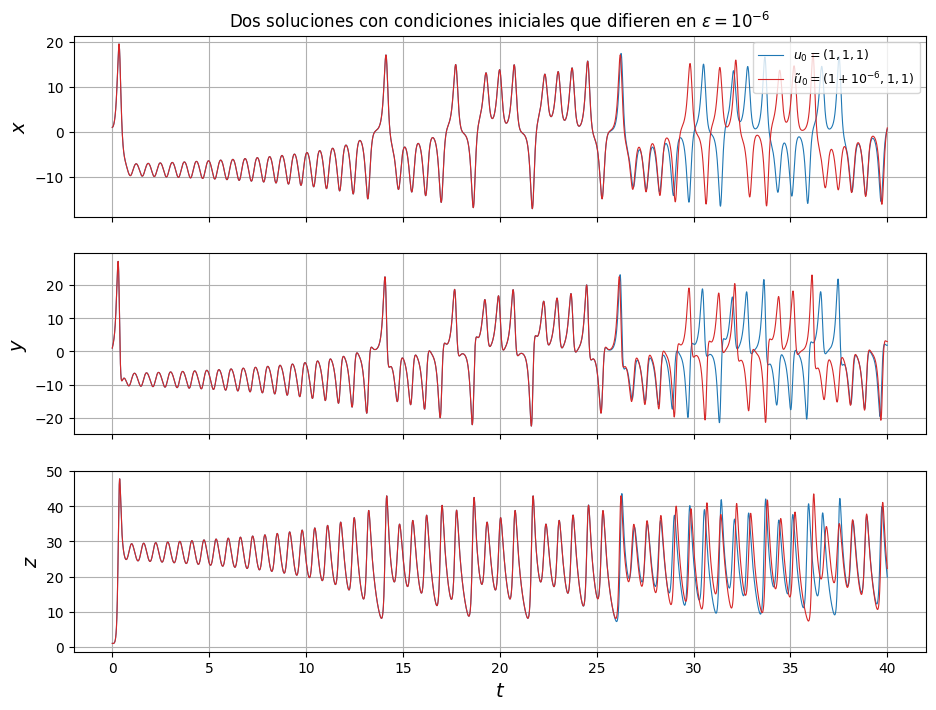

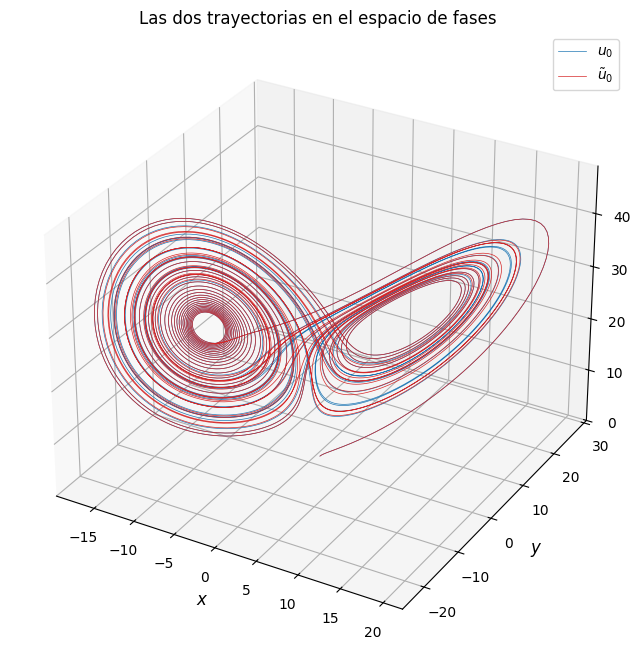

In [18]:
eps = 1e-6
u0 = [1.0, 1.0, 1.0]
u0_tilde = [1.0 + eps, 1.0, 1.0]

sol = solve_ivp(f, (0, T), u0, method="RK45", t_eval=tiempos, rtol=1e-8, atol=1e-10)
sol_tilde = solve_ivp(f, (0, T), u0_tilde, method="RK45", t_eval=tiempos, rtol=1e-8, atol=1e-10)
U, U_tilde = sol.y.T, sol_tilde.y.T

fig, ejes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for k, var in enumerate(["x", "y", "z"]):
    ejes[k].plot(t, U[:, k], "tab:blue", linewidth=0.8, label=r"$u_0 = (1, 1, 1)$")
    ejes[k].plot(t, U_tilde[:, k], "tab:red", linewidth=0.8, label=r"$\tilde u_0 = (1 + 10^{-6}, 1, 1)$")
    ejes[k].set_ylabel(f"${var}$", fontsize=14)
    ejes[k].grid()
ejes[0].legend(loc="upper right", fontsize=9)
ejes[2].set_xlabel(r"$t$", fontsize=14)
ejes[0].set_title(r"Dos soluciones con condiciones iniciales que difieren en $\varepsilon = 10^{-6}$")
plt.show()

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection="3d")
ax.plot(U[:, 0], U[:, 1], U[:, 2], "tab:blue", linewidth=0.5, label=r"$u_0$")
ax.plot(U_tilde[:, 0], U_tilde[:, 1], U_tilde[:, 2], "tab:red", linewidth=0.5, label=r"$\tilde u_0$")
ax.set_xlabel("$x$", fontsize=12); ax.set_ylabel("$y$", fontsize=12); ax.set_zlabel("$z$", fontsize=12)
ax.set_title("Las dos trayectorias en el espacio de fases")
ax.legend()
plt.show()

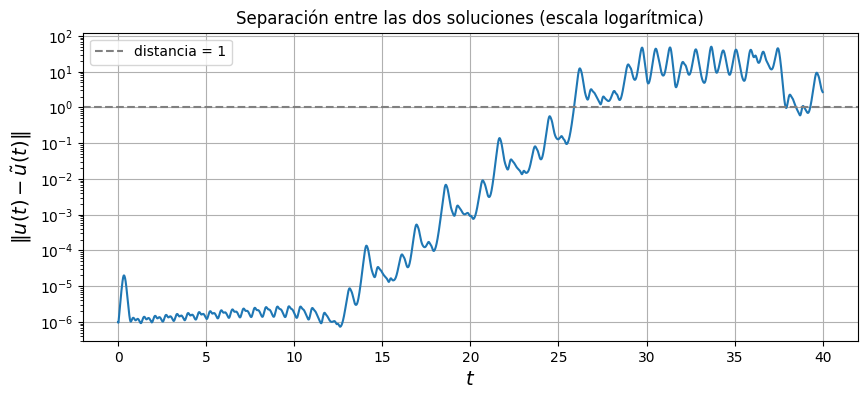

la distancia supera 1e-4 (cien veces la perturbación) por primera vez en t = 14.02
la distancia supera 1 por primera vez en t = 25.88
distancia máxima alcanzada: 50.09  (el atractor mide alrededor de40-50 unidades de lado)
pendiente de ln(distancia) contra t en esa zona: 0.86
es decir, la separación se multiplica por e cada 1.16 unidades de tiempo


In [19]:
dist = np.linalg.norm(U - U_tilde, axis=1)

plt.figure(figsize=(10, 4))
plt.semilogy(t, dist)
plt.axhline(1, color="gray", linestyle="--", label="distancia = 1")
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$\|u(t) - \tilde u(t)\|$", fontsize=14)
plt.title("Separación entre las dos soluciones (escala logarítmica)")
plt.legend()
plt.grid()
plt.show()

t_despega = t[np.argmax(dist > 1e-4)]
t_sep = t[np.argmax(dist > 1)]
print("la distancia supera 1e-4 (cien veces la perturbación) por primera vez en t =", round(t_despega, 2))
print("la distancia supera 1 por primera vez en t =", round(t_sep, 2))
print("distancia máxima alcanzada:", round(dist.max(), 2), " (el atractor mide alrededor de40-50 unidades de lado)")

mascara = (t > t_despega) & (dist < 1e-1)
pendiente = np.polyfit(t[mascara], np.log(dist[mascara]), 1)[0]
print("pendiente de ln(distancia) contra t en esa zona:", round(pendiente, 3))
print("es decir, la separación se multiplica por e cada", round(1/pendiente, 2), "unidades de tiempo")

### Actividad 5

Las dos soluciones empiezan a distancia $10^{-6}$ y durante los primeros 13 segundos la distancia casi no cambia: ambas giran alrededor del mismo punto fijo y las curvas son indistinguibles. Hacia $t \approx 14$ empiezan a saltar de lóbulo y la distancia crece exponencialmente, con pendiente 0.86 en la escala logarítmica. En $t = 25.88$ la distancia pasa de 1 y a partir de ahí las soluciones ya no se parecen: una cambia de lóbulo cuando la otra no, y la distancia llega hasta 50, el tamaño del atractor. O sea, no permanecen cercanas, y achicar la perturbación no ayuda mucho: con $10^{-12}$ sólo ganaríamos unos $\ln(10^6)/0.86 \approx 16$ segundos. Esa pendiente de 0.86 es una estimación del exponente de Lyapunov máximo, cuyo valor conocido es cercano a 0.9. Aun así, en el espacio de fases las dos trayectorias dibujan la misma mariposa: la forma del atractor se conserva, pero no se puede predecir en qué lóbulo estará el sistema en un momento dado.

## Reflexión final

Generalmente, cada representación responde algo distinto y ninguna sustituye a las otras. El campo de direcciones se dibuja sin resolver nada y ya muestra hacia dónde va el sistema: en Lotka-Volterra los signos de las derivadas bastan para ver que hay ciclos, y en el péndulo se ve que $\theta = 0$ es un centro y $\theta = \pi$ una silla. El espacio de fases muestra la forma de las soluciones: las órbitas cerradas de Lotka-Volterra, la separatriz del péndulo, la mariposa de Lorenz. Las gráficas temporales dicen cuándo pasan las cosas: el desfase entre presas y depredadores, el periodo del péndulo, el momento en que las soluciones de Lorenz se separan. Una órbita cerrada no dice cuánto tarda, y una gráfica temporal no deja ver tan fácil si el movimiento es oscilación o rotación.

Tres cosas sorrpenden. En Lotka-Volterra, que el periodo dependa de la condición inicial. En el péndulo, que empezando en $\pi - 0.05$ la curva se vea como de otro sistema y el periodo se triplique. En Lorenz, que la distancia entre las dos soluciones se quede en $10^{-6}$ al principio y sólo crezca cuando empiezan a saltar de lóbulo, y que la pendiente medida, 0.86, quede tan cerca del exponente de Lyapunov conocido.

La idea de resolver un sistema es completamente diferente aquí. No tenemos fórmula para ninguno de los tres, y en Lorenz no serviría de mucho, porque cualquier error inicial crece hasta el tamaño del atractor en unos 25 segundos; lo que sí se puede afirmar es cualitativo: hay ciclos, hay una separatriz, hay un atractor con dos lóbulos. Los tres sistemas tienen ecuaciones sencillas, pero dos son regulares y uno es caótico, y las simulaciones numéricas permiten ver esa diferencia sin resolver nada a mano.